# Mirror-CFE: Fashion-MNIST Trouser vs. Dress

Faithful-Port des **Chest-X-Ray** Mirror-CFE-Evaluationsnotebooks auf Fashion-MNIST Trouser/Dress und das lokale **ResNet-18**. Mirror-Kernlogik, voller Mirror-Decoder (SSC+SPE+CSP) und alle Metriken sind **identisch** zur X-Ray-Version. Geaendert ist nur das vom neuen ResNet/28x28/1-Kanal Erzwungene:
- Klassifikator-Zugriff via torchvision (`layer4`, `fc`) statt `encoder.blocks[-1]` / `decoder.decoder`.
- MNIST-Daten 7/9, 28x28, 1-Kanal, Fashion-MNIST-Normalisierung; Feature-Map 512x4x4.
- LPIPS/FID bekommen den 1-Kanal auf 3 Kanaele repliziert.
- **EBPG entfaellt** (Fashion-MNIST hat keine Bounding-Boxen).

Voraussetzung: `fashionmnist_trouser_dress_resnet18.pth` und `mirror_decoder_fashionmnist.pth` (aus `mirror-decoder-mnist.ipynb`).

## 1. Imports & Konfiguration

In [1]:
import os
import ssl
import numpy as np
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

try:
    import certifi
    ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())
except ImportError:
    ssl._create_default_https_context = ssl._create_unverified_context

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
from torch.utils.data import DataLoader, Subset
from torchvision import transforms, datasets
from torchvision.models import resnet18

torch.manual_seed(2024)
np.random.seed(2024)
DEVICE = torch.device('cuda' if torch.cuda.is_available()
                      else 'mps' if torch.backends.mps.is_available() else 'cpu')
print('Geraet:', DEVICE)

PROJ = Path.cwd()
while PROJ.name and not (PROJ / 'fashionmnist_trouser_dress_resnet18.pth').exists() and PROJ != PROJ.parent:
    PROJ = PROJ.parent
DATA_DIR    = PROJ / 'data'
PTH_PATH    = PROJ / 'fashionmnist_trouser_dress_resnet18.pth'
DECODER_PTH = PROJ / 'Counterfactuals' / 'Mirror' / 'mirror_decoder_fashionmnist.pth'
OUT_DIR     = PROJ / 'Counterfactuals' / 'Mirror'

IMG_SIZE    = 28
BATCH_SIZE  = 16
MEAN, STD   = 0.2860, 0.3530
DIGITS      = (1, 3)   # Trouser=1, Dress=3
CLASS_NAMES = {0: 'Trouser', 1: 'Dress'}      # Trouser -> 0, Dress -> 1

print('Modell  vorhanden:', PTH_PATH.exists())
print('Decoder vorhanden:', DECODER_PTH.exists())

Geraet: mps
Modell  vorhanden: True
Decoder vorhanden: True


## 2. Datensatz — Fashion-MNIST Trouser vs. Dress

In [2]:
eval_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((MEAN,), (STD,)),
])

def mnist_subset(train):
    ds = datasets.FashionMNIST(root=str(DATA_DIR), train=train, download=True, transform=eval_transforms)
    idx = torch.where((ds.targets == DIGITS[0]) | (ds.targets == DIGITS[1]))[0]
    ds.targets = (ds.targets == DIGITS[1]).long()
    return ds, idx.tolist()

# Test-Split = Val der Decoder-Version (Fashion-MNIST-Test, 7/9)
base_ds, test_indices = mnist_subset(train=False)
test_dataset = Subset(base_ds, test_indices)
print('Test-Set:', len(test_dataset))

Test-Set: 2037


## 3. DataLoader

In [3]:
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True,
                         num_workers=0, pin_memory=False)
print(f'Test-Set: {len(test_dataset)} Bilder | Batches: {len(test_loader)}')

Test-Set: 2037 Bilder | Batches: 128


## 4. Modell laden

torchvision-ResNet-18 (1-Kanal-Stem, kein MaxPool, fc->2), geladen aus `fashionmnist_trouser_dress_resnet18.pth`.

In [4]:
def build_model():
    m = resnet18(weights=None)
    m.conv1 = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=False)
    m.maxpool = nn.Identity()
    m.fc = nn.Linear(512, 2)
    return m

model = build_model().to(DEVICE)
model.load_state_dict(torch.load(PTH_PATH, map_location=DEVICE))
model.eval()
for p in model.parameters():
    p.requires_grad = False
print('Modell geladen')
with torch.no_grad():
    dummy = torch.zeros(2, 1, IMG_SIZE, IMG_SIZE).to(DEVICE)
    print('Output-Shape:', tuple(model(dummy).shape))

Modell geladen
Output-Shape: (2, 2)


## 5. Mirror-CFE Kernfunktionen

Identisch zur X-Ray-Version; nur die Modul-Zugriffe sind torchvision (`layer4`, `fc`). Die Mirror-Feature-Map ist `(B,512,4,4)`.

In [5]:
def extract_feature_maps(model, images):
    """Letzte Encoder-Feature-Map. Rueckgabe: (B, 512, 4, 4)"""
    feat = []
    hook = model.layer4.register_forward_hook(lambda m, i, o: feat.append(o))
    with torch.no_grad():
        _ = model(images)
    hook.remove()
    return feat[0]

def get_boundary_params(model):
    """Entscheidungsgrenze: Wm = W[1]-W[0], bm = b[1]-b[0] (Richtung Klasse 1)."""
    W  = model.fc.weight.data   # (2, 512)
    b  = model.fc.bias.data     # (2,)
    return (W[1] - W[0]).clone(), (b[1] - b[0]).clone()

def position_function(zs_batch, Wm, bm, k):
    """Paper Eq. 1: P(zs, Wm, bm, k) = zs - 2k*(Wm^T*zs+bm)*W_hat (auf der Feature-Map)."""
    B, C, H, W = zs_batch.shape
    W_hat   = Wm / (Wm.norm() + 1e-8)
    zs_flat = zs_batch.view(B, C, -1)
    dot     = (Wm.view(1, C, 1) * zs_flat).sum(dim=1, keepdim=True)
    scalar  = dot + bm.item()
    delta   = 2 * k * scalar * W_hat.view(1, C, 1)
    return (zs_flat - delta).view(B, C, H, W)

def compute_flk(f4_s, zs, Wm, bm, k):
    """Supp. Eq. 17: IN-DISTRIBUTION KFE-Map, GAP(f^l_k)=z_k (Train==Eval)."""
    B, C, H, Wd = f4_s.shape
    W_hat = Wm / (Wm.norm() + 1e-8)
    dot   = (Wm.view(1, C) * zs).sum(1, keepdim=True) + bm
    z_delta = -2.0 * k * dot * W_hat.view(1, C)
    zk  = zs + z_delta
    flk = f4_s + z_delta.view(B, C, 1, 1)
    return flk, zk

def refine_with_lbfgs(model, zr_init, source_labels, cfe_labels, orig_probs_2cls, num_iterations=20):
    """L-BFGS Verfeinerung der Mirror-Feature-Map bis Zielklasse erreicht."""
    swapped = orig_probs_2cls.clone().detach()
    idx = torch.arange(len(cfe_labels))
    src = source_labels.view(-1); cfe = cfe_labels.view(-1)
    tmp = swapped[idx, cfe].clone()
    swapped[idx, cfe] = swapped[idx, src]; swapped[idx, src] = tmp

    z = Variable(zr_init.clone().detach(), requires_grad=True)
    optimizer = torch.optim.LBFGS([z], lr=0.1)
    def closure():
        optimizer.zero_grad()
        pooled = F.adaptive_avg_pool2d(z, (1, 1))
        flat   = torch.flatten(pooled, 1)
        probs  = torch.softmax(model.fc(flat), dim=1)
        loss   = torch.norm(probs - swapped) ** 2
        loss.backward(); return loss
    for _ in range(num_iterations):
        optimizer.step(closure)
    return z

def compute_mirror_cfe(model, images, device, num_iterations=20):
    """Vollstaendige Mirror-CFE Pipeline."""
    model.eval()
    images = images.to(device)
    with torch.no_grad():
        logits        = model(images)
        probs         = torch.softmax(logits, dim=1)
        orig_probs    = probs[:, 1]
        source_labels = logits.argmax(dim=1)
        cfe_labels    = 1 - source_labels
    zs     = extract_feature_maps(model, images)
    Wm, bm = get_boundary_params(model); Wm, bm = Wm.to(device), bm.to(device)
    with torch.no_grad():
        zr_geometric = position_function(zs.clone(), Wm, bm, k=1.0)
    mirror_fv = refine_with_lbfgs(model, zr_geometric, source_labels, cfe_labels,
                                  probs.clone(), num_iterations=num_iterations)
    return mirror_fv, cfe_labels, source_labels, orig_probs

print('Mirror-CFE Funktionen definiert')

Mirror-CFE Funktionen definiert


## 6. Hilfsfunktionen

In [6]:
def denormalise(tensor):
    return (tensor * STD + MEAN).clamp(0, 1)

def predict_from_features(model, feature_maps):
    """Gibt P(Klasse 1 = 'Dress') zurueck."""
    with torch.no_grad():
        pooled = F.adaptive_avg_pool2d(feature_maps, (1, 1))
        flat   = torch.flatten(pooled, 1)
        probs  = torch.softmax(model.fc(flat), dim=1)[:, 1]
    return probs

print('Hilfsfunktionen definiert')

Hilfsfunktionen definiert


## 7. Visualisierungsfunktion

KFE-Uebergang k=0..1 (Feature-Map-Heatmaps) + Konfidenz-Journey (Paper Fig. 3). Ohne BBox (MNIST).

In [7]:
def generate_kfe_transitions(zs, zr, k_steps=None):
    if k_steps is None:
        k_steps = [0.0, 0.25, 0.5, 0.6, 0.75, 1.0]
    transitions = []
    with torch.no_grad():
        for k in k_steps:
            transitions.append((1 - k) * zs + k * zr.detach())
    return transitions, k_steps

def visualise_cfe(model, images, labels, fnames, mirror_fv, cfe_labels, source_labels,
                  orig_probs, class_names, n_samples=4, save_path='mirror_cfe.png'):
    model.eval()
    images = images.to(DEVICE)
    n = min(n_samples, images.size(0))
    source_fv = extract_feature_maps(model, images[:n])
    k_steps = [0.0, 0.25, 0.5, 0.6, 0.75, 1.0]
    transitions, ks = generate_kfe_transitions(source_fv, mirror_fv[:n], k_steps)
    conf_matrix = [predict_from_features(model, zk).cpu().numpy() for zk in transitions]
    with torch.no_grad():
        cfe_probs = predict_from_features(model, mirror_fv[:n]).cpu().numpy()
    orig_probs_np = orig_probs[:n].detach().cpu().numpy()

    n_cols = 2 + len(k_steps)
    fig = plt.figure(figsize=(n_cols * 2.2, n * 2.8))
    gs  = gridspec.GridSpec(n, n_cols, figure=fig, hspace=0.6, wspace=0.3)
    k_labels = ['k=0\n(Quelle)', 'k=0.25', 'k=0.5\n(Grenze)',
                'k=0.6\n(1. CFE)', 'k=0.75', 'k=1.0\n(Reflexion)']

    for i in range(n):
        img_np  = denormalise(images[i, 0].cpu()).numpy()
        src_lbl = source_labels[i].item(); cfe_lbl = cfe_labels[i].item()
        true_lbl = int(labels[i]); flipped = int(cfe_probs[i] >= 0.5) == cfe_lbl

        ax0 = fig.add_subplot(gs[i, 0]); ax0.imshow(img_np, cmap='gray')
        pred_col = 'limegreen' if src_lbl == true_lbl else 'tomato'
        ax0.set_title(f'Original\nWahr: {class_names[true_lbl]}\n'
                      f'Pred: {class_names[src_lbl]}\n({orig_probs_np[i]:.1%})',
                      fontsize=7, color=pred_col); ax0.axis('off')

        for j, k_lbl in enumerate(k_labels):
            ax = fig.add_subplot(gs[i, j + 1])
            hmap = transitions[j][i].detach().cpu().mean(0).numpy()
            hmap = (hmap - hmap.min()) / (hmap.max() + 1e-8)
            ax.imshow(hmap, cmap='hot', interpolation='bilinear', vmin=0, vmax=1)
            p_k = conf_matrix[j][i]; pred_at_k = class_names[int(p_k >= 0.5)]
            cross_col = 'cyan' if (int(p_k >= 0.5) == cfe_lbl) else 'white'
            ax.text(0.5, 0.02, f'P(Dress)={p_k:.2f}\n{pred_at_k}', transform=ax.transAxes,
                    ha='center', va='bottom', fontsize=6, color=cross_col,
                    bbox=dict(facecolor='black', alpha=0.5, pad=1))
            if abs(k_steps[j] - 0.5) < 0.01:
                for sp in ax.spines.values(): sp.set_edgecolor('cyan'); sp.set_linewidth(2)
            if k_steps[j] == 0.6:
                fc = 'limegreen' if flipped else 'tomato'
                for sp in ax.spines.values(): sp.set_edgecolor(fc); sp.set_linewidth(2)
            ax.set_title(k_lbl, fontsize=6.5); ax.set_xticks([]); ax.set_yticks([])

        ax_conf = fig.add_subplot(gs[i, -1])
        confs_i = [conf_matrix[j][i] for j in range(len(ks))]
        ax_conf.plot(ks, confs_i, 'o-', color='steelblue', lw=2, ms=4)
        ax_conf.axhline(0.5, color='k', ls='--', lw=1)
        ax_conf.axvline(0.5, color='cyan', ls=':', lw=1)
        for k, p in zip(ks, confs_i):
            if int(p >= 0.5) == cfe_lbl:
                ax_conf.scatter([k], [p], color='limegreen', s=60, zorder=5); break
        ax_conf.set_xlim(-0.05, 1.05); ax_conf.set_ylim(-0.05, 1.1)
        ax_conf.set_xlabel('k', fontsize=7); ax_conf.tick_params(labelsize=6)
        fc = 'limegreen' if flipped else 'tomato'
        ax_conf.set_title(f'{class_names[src_lbl]} -> {class_names[cfe_lbl]}\n'
                          f'{"gekippt" if flipped else "nicht gekippt"}', fontsize=7, color=fc)

    plt.suptitle('Mirror-CFE — KFE Uebergang (k=0..1) | Cyan=Grenze | Gruen/Rot=1. CFE',
                 fontsize=11, y=1.01)
    plt.savefig(save_path, dpi=120, bbox_inches='tight'); plt.show()
    print(f'Gespeichert -> {save_path}')

print('Visualisierungsfunktion definiert')

Visualisierungsfunktion definiert


## 8. Sanity Check — Flip Rate

In [8]:
sample_images, sample_labels = next(iter(test_loader))
sample_fnames = [str(i) for i in range(len(sample_labels))]

mirror_fv, cfe_labels, source_labels, orig_probs = compute_mirror_cfe(
    model, sample_images, DEVICE, num_iterations=20)

cfe_probs = predict_from_features(model, mirror_fv).cpu()
cfe_preds = (cfe_probs >= 0.5).long()
flip_rate = (cfe_preds == cfe_labels.cpu()).float().mean()

print(f'Batch-Groesse : {len(sample_labels)}')
print(f'Flip Rate     : {flip_rate:.2%}  (Ziel: >80%)')
print(f'Quellvorhers. : {[CLASS_NAMES[s] for s in source_labels[:8].tolist()]}')
print(f'Zielklassen   : {[CLASS_NAMES[t] for t in cfe_labels[:8].tolist()]}')
if flip_rate < 0.8:
    print('\nWARNUNG Flip Rate niedrig — num_iterations erhoehen')

Batch-Groesse : 16
Flip Rate     : 100.00%  (Ziel: >80%)
Quellvorhers. : ['7', '9', '7', '9', '9', '9', '9', '9']
Zielklassen   : ['9', '7', '9', '7', '7', '7', '7', '7']


## 9. Visualisierung ausfuehren

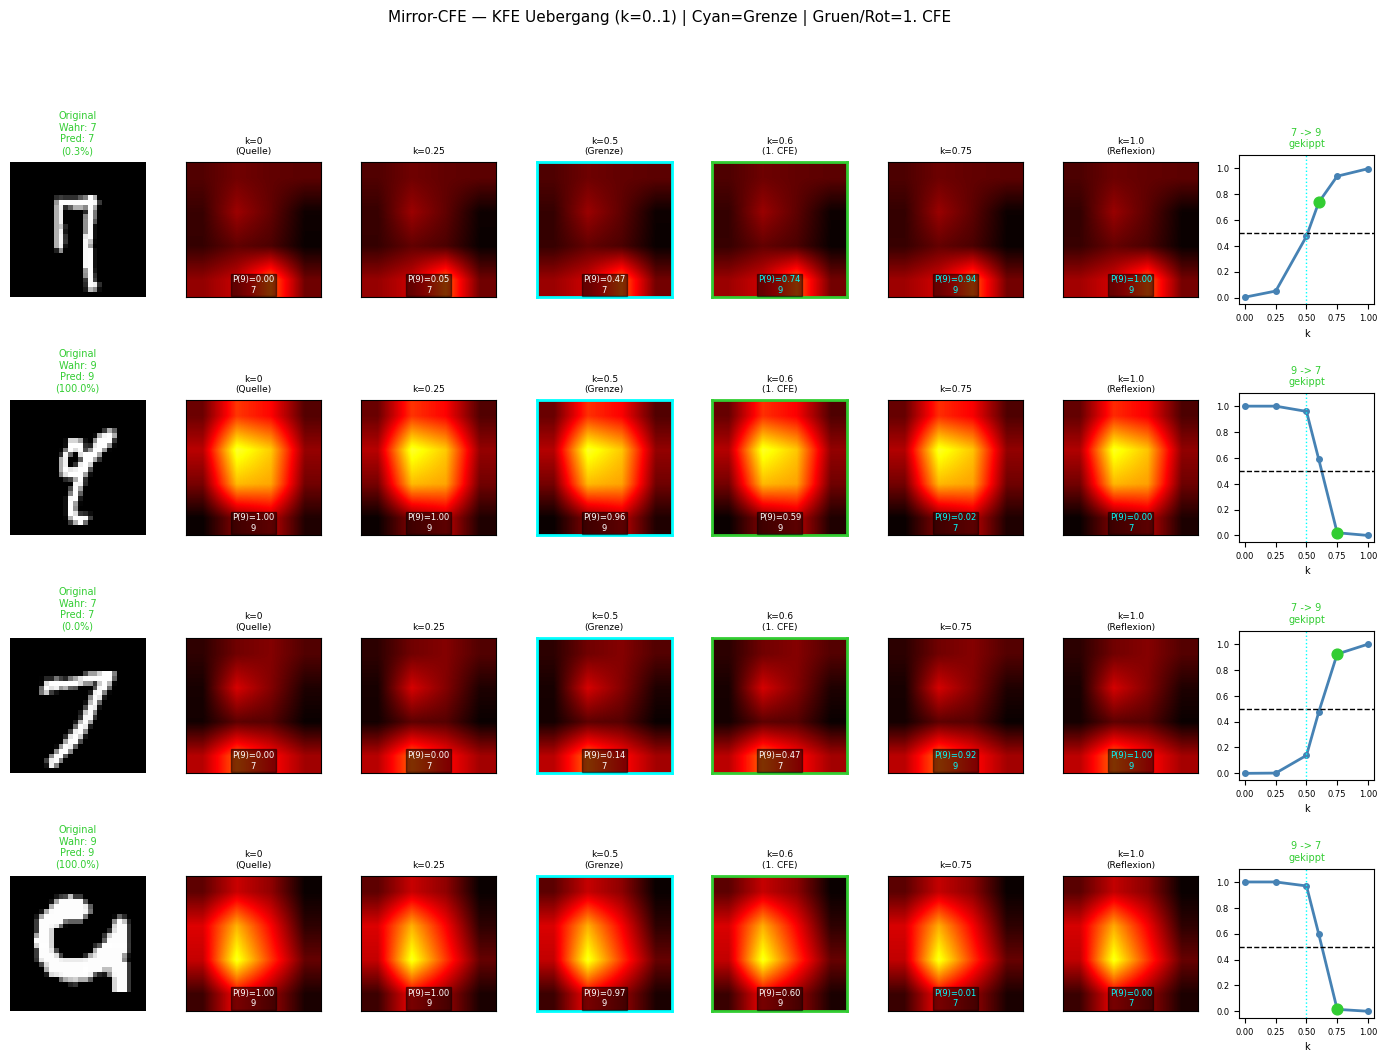

Gespeichert -> /Users/sophiapaoli/Nextcloud/Documents/Master/Semester_2/Praxisseminar/Explaining_Image_Classification/Counterfactuals/Mirror/mirror_cfe_mnist.png


In [9]:
visualise_cfe(
    model=model, images=sample_images, labels=sample_labels, fnames=sample_fnames,
    mirror_fv=mirror_fv, cfe_labels=cfe_labels, source_labels=source_labels,
    orig_probs=orig_probs, class_names=CLASS_NAMES, n_samples=4,
    save_path=str(OUT_DIR / 'mirror_cfe_fashionmnist.png'))

## 10. Batch-Evaluation (Latent-Flip)

In [10]:
n_batches = 10
total_flip = total_images = 0
for batch_imgs, batch_lbls in tqdm(list(test_loader)[:n_batches], desc='CFE Evaluation'):
    m_fv, c_lbls, s_lbls, o_probs = compute_mirror_cfe(model, batch_imgs, DEVICE, num_iterations=20)
    cfe_p = predict_from_features(model, m_fv).cpu()
    preds = (cfe_p >= 0.5).long()
    total_flip   += (preds == c_lbls.cpu()).sum().item()
    total_images += len(batch_lbls)
print(f'\nLatent-Flip Rate: {total_flip}/{total_images} = {total_flip/total_images:.2%}')

CFE Evaluation: 100%|██████████| 10/10 [00:15<00:00,  1.59s/it]


Latent-Flip Rate: 160/160 = 100.00%


## 11. Mirror-Decoder laden & dekodierte CFE-Bilder

Voller Mirror-Decoder (SSC+SPE+CSP) wie im Decoder-Notebook (inkl. MPS-sicherem Adaptive-Pool). Drei-Panel-Visualisierung: Original | CFE | Differenz.

Mirror-Decoder (mit SSC) geladen


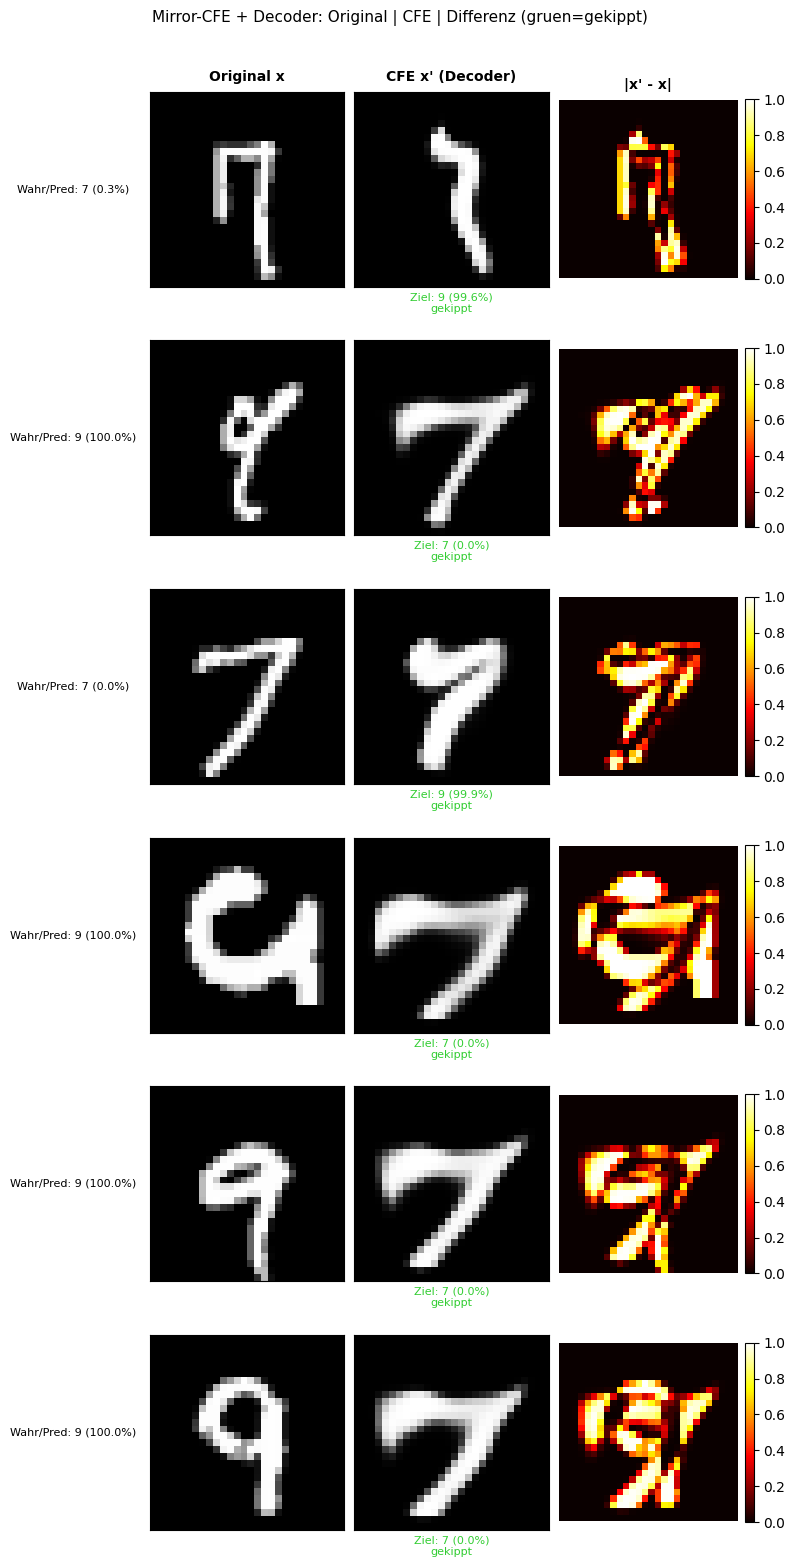

Gespeichert -> /Users/sophiapaoli/Nextcloud/Documents/Master/Semester_2/Praxisseminar/Explaining_Image_Classification/Counterfactuals/Mirror/mirror_cfe_decoded_mnist.png


In [11]:
# MPS-sicherer Adaptive-Pool (14->4 etc. auf MPS nicht unterstuetzt)
def _safe_adaptive_pool(x, size):
    if x.device.type == 'mps':
        return F.adaptive_avg_pool2d(x.cpu(), size).to(x.device)
    return F.adaptive_avg_pool2d(x, size)

class SPEBlock(nn.Module):
    def __init__(self, Ci, Hi, flk_ch=512, bottleneck_ch=128, flk_hw=4):
        super().__init__()
        self.Hi = Hi; self.flk_hw = flk_hw
        self.bottleneck = nn.Sequential(
            nn.Conv2d(Ci, bottleneck_ch, 1, bias=False),
            nn.BatchNorm2d(bottleneck_ch), nn.ReLU(inplace=True))
        self.decoder = nn.Sequential(
            nn.Conv2d(bottleneck_ch + flk_ch, Ci, 3, padding=1),
            nn.BatchNorm2d(Ci), nn.ReLU(inplace=True),
            nn.Upsample(size=(Hi, Hi), mode='bilinear', align_corners=False),
            nn.Conv2d(Ci, Ci, 3, padding=1),
            nn.BatchNorm2d(Ci), nn.ReLU(inplace=True))
    def forward(self, fi_s, flk):
        bi  = _safe_adaptive_pool(self.bottleneck(fi_s), (self.flk_hw, self.flk_hw))
        return self.decoder(torch.cat([bi, flk], dim=1))

class SSC(nn.Module):
    def __init__(self, rho_l=0.1, rho_u=0.5):
        super().__init__()
        self.rho_l, self.rho_u = rho_l, rho_u
        self.spe1 = SPEBlock(64, 28); self.spe2 = SPEBlock(128, 14); self.spe3 = SPEBlock(256, 7)
    def csp_mask(self, flk, W, k, thw, src, tgt):
        B, C, H, Wd = flk.shape
        Uk = F.relu(torch.einsum('oc,bchw->bohw', W, flk))
        Nk = Uk / (Uk.amax(dim=(2, 3), keepdim=True) + 1e-8)
        rho = min(max(1.0 - k, self.rho_l), self.rho_u)
        idx = torch.arange(B, device=flk.device)
        Ns = (Nk[idx, src].unsqueeze(1) > rho).float()
        Nt = (Nk[idx, tgt].unsqueeze(1) > rho).float()
        M  = torch.clamp(Ns + Nt, 0, 1)
        return F.interpolate(M, size=thw, mode='nearest')
    def forward(self, f1, f2, f3, flk, W, k, src, tgt):
        u1, u2, u3 = self.spe1(f1, flk), self.spe2(f2, flk), self.spe3(f3, flk)
        m1 = self.csp_mask(flk, W, k, (28, 28), src, tgt)
        m2 = self.csp_mask(flk, W, k, (14, 14), src, tgt)
        m3 = self.csp_mask(flk, W, k, (7, 7), src, tgt)
        return (1-m1)*f1+m1*u1, (1-m2)*f2+m2*u2, (1-m3)*f3+m3*u3

class MirrorDecoder(nn.Module):
    def __init__(self, rho_l=0.1, rho_u=0.5):
        super().__init__()
        self.ssc = SSC(rho_l, rho_u)
        self.up1 = self._up(512, 256, 7)
        self.up2 = self._up(512, 128, 14)
        self.up3 = self._up(256, 64, 28)
        self.up4 = self._conv(128, 32)
        self.out_conv = nn.Sequential(nn.Conv2d(32, 1, 3, padding=1), nn.Tanh())
    def _up(self, ic, oc, size):
        return nn.Sequential(
            nn.Upsample(size=(size, size), mode='bilinear', align_corners=False),
            nn.Conv2d(ic, oc, 3, padding=1), nn.BatchNorm2d(oc), nn.ReLU(inplace=True),
            nn.Conv2d(oc, oc, 3, padding=1), nn.BatchNorm2d(oc), nn.ReLU(inplace=True))
    def _conv(self, ic, oc):
        return nn.Sequential(
            nn.Conv2d(ic, oc, 3, padding=1), nn.BatchNorm2d(oc), nn.ReLU(inplace=True),
            nn.Conv2d(oc, oc, 3, padding=1), nn.BatchNorm2d(oc), nn.ReLU(inplace=True))
    def _decode(self, flk, fp1, fp2, fp3):
        x = self.up1(flk); x = torch.cat([x, fp3], 1)
        x = self.up2(x);   x = torch.cat([x, fp2], 1)
        x = self.up3(x);   x = torch.cat([x, fp1], 1)
        x = self.up4(x)
        return self.out_conv(x)
    def forward(self, flk, f1, f2, f3, W, k, src, tgt):
        fp1, fp2, fp3 = self.ssc(f1, f2, f3, flk, W, k, src, tgt)
        return self._decode(flk, fp1, fp2, fp3)

def extract_all_features(model, images):
    feats = {}; hooks = []
    lm = {'f1': model.layer1, 'f2': model.layer2, 'f3': model.layer3, 'f4': model.layer4}
    for n, l in lm.items():
        hooks.append(l.register_forward_hook(lambda m, i, o, n=n: feats.update({n: o})))
    with torch.no_grad(): _ = model(images)
    for h in hooks: h.remove()
    return feats['f1'], feats['f2'], feats['f3'], feats['f4']

def tanh_to_img(t): return (t + 1.0) / 2.0
def gap(f): return F.adaptive_avg_pool2d(f, (1, 1)).flatten(1)

dec_ckpt = torch.load(DECODER_PTH, map_location=DEVICE, weights_only=False)
decoder  = MirrorDecoder(rho_l=0.1, rho_u=0.5).to(DEVICE)
decoder.load_state_dict(dec_ckpt['model_state_dict'])
decoder.eval()
Wmat = model.fc.weight.data.clone().to(DEVICE)
print('Mirror-Decoder (mit SSC) geladen')

def visualise_decoder_cfe(model, decoder, images, labels, fnames, mirror_fv,
                          cfe_labels, source_labels, orig_probs, class_names,
                          n_samples=6, save_path='mirror_cfe_decoded.png'):
    model.eval(); decoder.eval()
    images = images.to(DEVICE); n = min(n_samples, images.size(0))
    f1, f2, f3, f4 = extract_all_features(model, images[:n])
    src_n = source_labels[:n].to(DEVICE); tgt_n = cfe_labels[:n].to(DEVICE)
    with torch.no_grad():
        cfe_imgs = decoder(mirror_fv[:n].detach(), f1, f2, f3, Wmat, 1.0, src_n, tgt_n)
    cfe_probs_val = predict_from_features(model, mirror_fv[:n]).cpu().numpy()
    orig_probs_np = orig_probs[:n].detach().cpu().numpy()

    fig, axes = plt.subplots(n, 3, figsize=(8, n * 2.6))
    if n == 1: axes = axes[np.newaxis, :]
    for col, t_ in enumerate(["Original x", "CFE x' (Decoder)", "|x' - x|"]):
        axes[0, col].set_title(t_, fontsize=10, fontweight='bold', pad=8)
    for i in range(n):
        orig_np = denormalise(images[i, 0].cpu()).numpy()
        cfe_np  = tanh_to_img(cfe_imgs[i, 0].detach().cpu()).numpy().clip(0, 1)
        diff_np = np.abs(cfe_np - orig_np)
        diff_np = (diff_np - diff_np.min()) / (diff_np.max() + 1e-8)
        src_lbl = source_labels[i].item(); cfe_lbl = cfe_labels[i].item()
        flipped = int(cfe_probs_val[i] >= 0.5) == cfe_lbl
        axes[i, 0].imshow(orig_np, cmap='gray')
        axes[i, 0].set_ylabel(f'Wahr/Pred: {class_names[src_lbl]} ({orig_probs_np[i]:.1%})',
                              fontsize=8, rotation=0, labelpad=55, va='center')
        axes[i, 0].set_xticks([]); axes[i, 0].set_yticks([])
        axes[i, 1].imshow(cfe_np, cmap='gray')
        fc = 'limegreen' if flipped else 'tomato'
        axes[i, 1].set_xlabel(f'Ziel: {class_names[cfe_lbl]} ({cfe_probs_val[i]:.1%})\n'
                              f'{"gekippt" if flipped else "nicht gekippt"}', fontsize=8, color=fc)
        axes[i, 1].set_xticks([]); axes[i, 1].set_yticks([])
        im = axes[i, 2].imshow(diff_np, cmap='hot', vmin=0, vmax=1)
        plt.colorbar(im, ax=axes[i, 2], fraction=0.046, pad=0.04); axes[i, 2].axis('off')
    plt.suptitle("Mirror-CFE + Decoder: Original | CFE | Differenz (gruen=gekippt)",
                 fontsize=11, y=1.005)
    plt.tight_layout()
    plt.savefig(save_path, dpi=120, bbox_inches='tight'); plt.show()
    print(f'Gespeichert -> {save_path}')

visualise_decoder_cfe(model, decoder, sample_images, sample_labels, sample_fnames,
                      mirror_fv, cfe_labels, source_labels, orig_probs, CLASS_NAMES,
                      n_samples=6, save_path=str(OUT_DIR / 'mirror_cfe_decoded_fashionmnist.png'))

## 12. Metrik-Funktionen

In [12]:
pip install lpips


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [13]:
import time
from scipy import linalg as scipy_linalg

try:
    import lpips
    lpips_fn = lpips.LPIPS(net='squeeze').to(DEVICE); lpips_fn.eval()
    LPIPS_AVAILABLE = True
    print('LPIPS geladen')
except Exception as e:
    LPIPS_AVAILABLE = False
    print('LPIPS nicht verfuegbar:', e)


def _decode_at_k(model, decoder, f1, f2, f3, f4, zs, Wm, bm, src, tgt, k):
    flk, zk = compute_flk(f4, zs, Wm, bm, k)
    return decoder(flk, f1, f2, f3, Wmat, k, src, tgt), zk

def get_cfe_image_from_mirror(model, decoder, images, k_eval=None, k_grid=None):
    """Paper-konsistente CFE-Bilderzeugung ueber analytisches flk (IN-DISTRIBUTION).
       k_eval=None -> pro Sample kleinstes flippendes k (1st CFE); k_eval=1.0 -> Reflexion.
       Rueckgabe: orig_np, cfe_np in [0,1], Form (B,H,W,1)."""
    images = images.to(DEVICE); n = images.size(0)
    f1, f2, f3, f4 = extract_all_features(model, images)
    Wm, bm = get_boundary_params(model); Wm, bm = Wm.to(DEVICE), bm.to(DEVICE)
    with torch.no_grad():
        src = model(images).argmax(dim=1); tgt = 1 - src
        zs  = gap(f4)
        if k_eval is not None:
            cfe_imgs, _ = _decode_at_k(model, decoder, f1, f2, f3, f4, zs, Wm, bm, src, tgt, float(k_eval))
        else:
            if k_grid is None:
                k_grid = [0.5 + 0.05 * i for i in range(1, 11)]
            best_imgs = None; k_used = torch.ones(n); found = torch.zeros(n, dtype=torch.bool)
            for k in k_grid:
                cfe_k, _ = _decode_at_k(model, decoder, f1, f2, f3, f4, zs, Wm, bm, src, tgt, float(k))
                cfe_img01 = tanh_to_img(cfe_k)
                pred = model((cfe_img01 - MEAN) / STD).argmax(dim=1)
                newly = (pred.cpu() == tgt.cpu()) & (~found)
                if best_imgs is None: best_imgs = cfe_k.clone()
                if newly.any():
                    best_imgs[newly] = cfe_k[newly]; k_used[newly] = float(k); found = found | newly
                if found.all(): break
            if (~found).any():
                cfe_1, _ = _decode_at_k(model, decoder, f1, f2, f3, f4, zs, Wm, bm, src, tgt, 1.0)
                best_imgs[~found] = cfe_1[~found]
            cfe_imgs = best_imgs
    orig_np = denormalise(images.cpu()).permute(0, 2, 3, 1).numpy()       # (B,H,W,1)
    cfe_np  = tanh_to_img(cfe_imgs.detach().cpu()).permute(0, 2, 3, 1).numpy().clip(0, 1)
    return orig_np, cfe_np


def _to_3ch(imgs_np):
    """(B,H,W,1) -> (B,H,W,3) durch Kanal-Replikation (fuer LPIPS/FID/Inception)."""
    if imgs_np.shape[-1] == 1:
        return np.repeat(imgs_np, 3, axis=-1)
    return imgs_np

# L1 (Wachter et al. 2017)
def compute_l1(orig_np, cfe_np):
    diffs = np.abs(orig_np - cfe_np)
    denom = orig_np.shape[1] * orig_np.shape[2] * orig_np.shape[3]
    return float((diffs.sum(axis=(1, 2, 3)) / denom).mean())

# Sparsity Rate (Moreira et al. 2025)
def compute_sparsity_rate(orig_np, cfe_np, threshold=1e-4):
    diff = np.abs(orig_np - cfe_np).mean(axis=-1)
    return float((diff > threshold).astype(float).mean(axis=(1, 2)).mean())

# LPIPS (Zhang et al. 2018)
def compute_lpips(orig_np, cfe_np):
    if not LPIPS_AVAILABLE: return None
    o = torch.tensor(_to_3ch(orig_np), dtype=torch.float32).permute(0, 3, 1, 2).to(DEVICE) * 2 - 1
    c = torch.tensor(_to_3ch(cfe_np),  dtype=torch.float32).permute(0, 3, 1, 2).to(DEVICE) * 2 - 1
    with torch.no_grad():
        scores = lpips_fn(o, c)
    return float(scores.mean().cpu())

# FID (InceptionV3, 2048-dim)
from torchvision.models import inception_v3
@torch.no_grad()
def extract_inception_features(imgs_np, batch_size=32):
    if not hasattr(extract_inception_features, '_model'):
        m = inception_v3(weights='DEFAULT', transform_input=False)
        m.fc = nn.Identity(); m = m.eval().to(DEVICE)
        extract_inception_features._model = m
    inc = extract_inception_features._model
    imgs_np = _to_3ch(imgs_np)
    feats = []
    for i in range(0, len(imgs_np), batch_size):
        t = torch.tensor(imgs_np[i:i+batch_size], dtype=torch.float32).permute(0, 3, 1, 2).to(DEVICE)
        t = F.interpolate(t, size=(299, 299), mode='bilinear', align_corners=False)
        feats.append(inc(t).cpu().numpy())
    return np.concatenate(feats, axis=0)

def compute_fid(real_np, fake_np):
    rf = extract_inception_features(real_np); ff = extract_inception_features(fake_np)
    mu_r, mu_f = rf.mean(0), ff.mean(0)
    sig_r, sig_f = np.cov(rf, rowvar=False), np.cov(ff, rowvar=False)
    diff = mu_r - mu_f
    covmean, _ = scipy_linalg.sqrtm(sig_r @ sig_f, disp=False)
    if np.iscomplexobj(covmean): covmean = covmean.real
    return float(diff @ diff + np.trace(sig_r + sig_f - 2 * covmean))

# Validity (Verma et al. 2022) + Denoised Validity
def compute_validity(model, cfe_imgs_tensor, cfe_labels, denoise_sigma=None):
    from torchvision.transforms.functional import gaussian_blur
    model.eval(); cfe_imgs_tensor = cfe_imgs_tensor.to(DEVICE)
    if denoise_sigma is not None:
        ks = max(int(denoise_sigma * 6) | 1, 3)
        cfe = gaussian_blur(cfe_imgs_tensor, kernel_size=[ks, ks], sigma=[denoise_sigma, denoise_sigma])
    else:
        cfe = cfe_imgs_tensor
    cfe_norm = (cfe - MEAN) / STD
    with torch.no_grad():
        preds = model(cfe_norm).argmax(dim=1).cpu()
    return float((preds == cfe_labels.cpu()).float().mean())

# Coverage (Moreira et al. 2025) — auf dem dekodierten 1st-CFE-Bild
def compute_coverage(model, decoder, images, n_runs=5, num_iterations=20):
    images = images.to(DEVICE); valid_runs = []
    for _ in range(n_runs):
        _, cfe_np = get_cfe_image_from_mirror(model, decoder, images, k_eval=None)
        with torch.no_grad():
            src = model(images).argmax(dim=1); c_lbls = 1 - src
        cfe_t = torch.tensor(cfe_np).permute(0, 3, 1, 2).float()
        valid_runs.append(compute_validity(model, cfe_t, c_lbls))
    return float(np.mean(valid_runs)), float(np.std(valid_runs))

print('Metrik-Funktionen definiert')

Setting up [LPIPS] perceptual loss: trunk [squeeze], v[0.1], spatial [off]
Loading model from: /Users/sophiapaoli/Nextcloud/Documents/Master/Semester_2/Praxisseminar/Explaining_Image_Classification/.venv/lib/python3.13/site-packages/lpips/weights/v0.1/squeeze.pth
LPIPS geladen
Metrik-Funktionen definiert


/Users/sophiapaoli/Nextcloud/Documents/Master/Semester_2/Praxisseminar/Explaining_Image_Classification/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/sophiapaoli/Nextcloud/Documents/Master/Semester_2/Praxisseminar/Explaining_Image_Classification/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=SqueezeNet1_1_Weights.IMAGENET1K_V1`. You can also use `weights=SqueezeNet1_1_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


## 13. Fester Eval-Satz

Wie X-Ray ein reproduzierbarer Satz (Seed 42); ohne BBox-Stratifizierung, da Fashion-MNIST keine Boxen hat.

In [14]:
EVAL_SEED     = 42
N_EVAL_IMAGES = 500

_rng = np.random.RandomState(EVAL_SEED)
_sel = list(test_indices)
_rng.shuffle(_sel)
eval_indices = _sel[:N_EVAL_IMAGES]
eval_dataset = Subset(base_ds, eval_indices)
eval_loader  = DataLoader(eval_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f'Fester Eval-Satz: {len(eval_indices)} Bilder (Seed {EVAL_SEED})')

Fester Eval-Satz: 80 Bilder (Seed 42)


## 14. Metriken berechnen & ausgeben

In [15]:
import time

DENOISE_SIGMA = 1.0

all_l1, all_sparsity, all_lpips = [], [], []
all_real_np, all_cfe_np = [], []
all_eval_imgs = []
all_cfe_tensor, all_cfe_labels = [], []
total_time = 0.0; n_images = 0

print(f'Berechne Metriken ueber {len(eval_dataset)} Bilder...')
print('-' * 60)
for batch_imgs, batch_lbls in tqdm(eval_loader, desc='Metrik-Evaluation'):
    t0 = time.time()
    m_fv, c_lbls, s_lbls, o_probs = compute_mirror_cfe(model, batch_imgs, DEVICE, num_iterations=20)
    total_time += time.time() - t0
    n_images   += len(batch_lbls)
    all_eval_imgs.append(batch_imgs.cpu())

    orig_np, cfe_np = get_cfe_image_from_mirror(model, decoder, batch_imgs, k_eval=None)
    all_l1.append(compute_l1(orig_np, cfe_np))
    all_sparsity.append(compute_sparsity_rate(orig_np, cfe_np))
    if LPIPS_AVAILABLE:
        all_lpips.append(compute_lpips(orig_np, cfe_np))
    all_real_np.append(orig_np); all_cfe_np.append(cfe_np)
    all_cfe_tensor.append(torch.tensor(cfe_np, dtype=torch.float32).permute(0, 3, 1, 2))
    all_cfe_labels.append(c_lbls.cpu())

real_all = np.concatenate(all_real_np, 0); cfe_all = np.concatenate(all_cfe_np, 0)
fid_score = compute_fid(real_all, cfe_all)

all_cfe_tensor_cat = torch.cat(all_cfe_tensor, 0)
all_cfe_labels_cat = torch.cat(all_cfe_labels, 0)
validity          = compute_validity(model, all_cfe_tensor_cat, all_cfe_labels_cat)
denoised_validity = compute_validity(model, all_cfe_tensor_cat, all_cfe_labels_cat, denoise_sigma=DENOISE_SIGMA)

print('Berechne Coverage (5 Runs)...')
eval_imgs_cat = torch.cat(all_eval_imgs, 0)
coverage_mean, coverage_std = compute_coverage(model, decoder, eval_imgs_cat, n_runs=5, num_iterations=20)
efficiency = total_time / n_images

print('\n' + '=' * 60)
print('METRIK-ERGEBNISSE — Mirror-CFE Fashion-MNIST Trouser vs. Dress')
print('=' * 60)
print('\n-- Proximity ----------------------------------------------')
print(f'  L1-Distanz:           {np.mean(all_l1):.4f}  (kleiner besser)')
print('\n-- Interpretierbarkeit ------------------------------------')
print(f'  Sparsity Rate:        {np.mean(all_sparsity):.4f}  (kleiner besser)')
if LPIPS_AVAILABLE:
    print(f'  LPIPS (SqueezeNet):   {np.mean(all_lpips):.4f}  (kleiner besser)')
else:
    print(f'  LPIPS:                nicht verfuegbar')
print('\n-- Plausibilitaet -----------------------------------------')
print(f'  FID:                  {fid_score:.2f}   (kleiner besser)')
print('\n-- Funktionalitaet ----------------------------------------')
print(f'  Validity:             {validity:.2%}  (groesser besser)')
print(f'  Denoised Validity:    {denoised_validity:.2%}  (groesser besser, sigma={DENOISE_SIGMA})')
print(f'  Delta Validity:       {validity - denoised_validity:.2%}  (kleiner = weniger adversarial)')
print(f'  Coverage:             {coverage_mean:.2%} +/- {coverage_std:.2%}  (groesser besser)')
print(f'  Efficiency:           {efficiency:.3f}s / CF  (kleiner besser)')
print('=' * 60)

Berechne Metriken ueber 80 Bilder...
------------------------------------------------------------


Metrik-Evaluation: 100%|██████████| 5/5 [00:08<00:00,  1.71s/it]
/var/folders/0y/p0v5xjdx3x5fjcmh8y1x5x_w0000gn/T/ipykernel_55996/842217895.py:100: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = scipy_linalg.sqrtm(sig_r @ sig_f, disp=False)
/var/folders/0y/p0v5xjdx3x5fjcmh8y1x5x_w0000gn/T/ipykernel_55996/842217895.py:100: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  covmean, _ = scipy_linalg.sqrtm(sig_r @ sig_f, disp=False)


Berechne Coverage (5 Runs)...

METRIK-ERGEBNISSE — Mirror-CFE MNIST 7 vs. 9

-- Proximity ----------------------------------------------
  L1-Distanz:           0.0910  (kleiner besser)

-- Interpretierbarkeit ------------------------------------
  Sparsity Rate:        0.4671  (kleiner besser)
  LPIPS (SqueezeNet):   0.0800  (kleiner besser)

-- Plausibilitaet -----------------------------------------
  FID:                  101.75   (kleiner besser)

-- Funktionalitaet ----------------------------------------
  Validity:             96.25%  (groesser besser)
  Denoised Validity:    38.75%  (groesser besser, sigma=1.0)
  Delta Validity:       57.50%  (kleiner = weniger adversarial)
  Coverage:             96.25% +/- 0.00%  (groesser besser)
  Efficiency:           0.084s / CF  (kleiner besser)
